In [23]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path

home = Path.home()
print(home)
if (home / "Desktop/doc/NPG").exists():
    BASE = str(home / "Desktop/doc/NPG")
    NOU  = f"{BASE}/fitxers/"
    ANT  = f"{BASE}/antfiles/"
else:
    BASE = str("/home/aressanuy/Desktop/doc/NPG/entropianou")
    NOU  = f"{BASE}/nou"
    ANT  = f"{BASE}/antic"

# ==================================================
# PARELLES (T_abans, T_despres, P)
# ==================================================

parelles = {
    1:    (300, 305),
    1000: (310, 315),
    2000: (320, 325),
    3000: (325, 330),
    4000: (330, 335),
    5000: (335, 340),
}

def nou_abans(P):
    t_abans, _ = parelles[P]
    return f"{NOU}/ang_ori_{t_abans}_{P}_2.dat"

def nou_despres(P):
    _, t_despres = parelles[P]
    return f"{NOU}/ang_ori_{t_despres}_{P}_2.dat"

def antic_abans(P):
    t_abans, _ = parelles[P]
    return f"{ANT}/ang_fix_{P}_{t_abans}.dat"

def antic_despres(P):
    _, t_despres = parelles[P]
    return f"{ANT}/ang_fix_{P}_{t_despres}.dat"

/Users/aressanuylatorre


In [24]:
# =========================
# CONSTANTS I CODIS
# =========================
k      = 1.380649e-23
mmol   = 0.10415        # kg/mol
nmol   = 512
NA     = 6.02214076e23
massa  = mmol/ NA   # kg (massa molecula del sistema)


def entropy_conf(fname, bins=70):
    """Entropia conformacional via histograma 2D (psi, phi)."""
    psi, phi = [], []
    with open(fname) as f:
        for _ in range(3):
            f.readline()
        for line in f:
            if not line.strip() or line.startswith('*'):
                continue
            cols = line.split()
            try:
                psi.append(float(cols[6]))
                phi.append(float(cols[7]))
            except (IndexError, ValueError):
                continue

    edges = np.linspace(-180, 180, bins + 1)
    hist, _, _ = np.histogram2d(psi, phi, bins=[edges, edges], density=True)
    Ap = 360 / bins
    p  = hist * Ap * Ap
    S  = -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(Ap * Ap)
    return S / massa 


def entropy_ori(fname, bins=100):
    """Entropia orientacional via histograma 3D (theta, phi, psi)."""
    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(4):
            f.readline()
        for line in f:
            cols = line.split()
            try:
                th.append(float(cols[8]))
                phi.append(float(cols[9]))
                psi.append(float(cols[10]))
            except (IndexError, ValueError):
                continue

    intervals = [
        np.linspace(-1,   1,   bins),
        np.linspace(-180, 180, bins),
        np.linspace(-180, 180, bins),
    ]
    hist, _ = np.histogramdd((th, phi, psi), bins=intervals, density=True)
    Ath = 2 / bins
    A   = Ath * (360 / bins) * (360 / bins)
    p   = hist * A
    S   = -k * np.sum(p[p > 0] * np.log(p[p > 0]))
    return S / massa

P=    1 bar  335→340 K Sc1=626.8855780862269 Sc2=777.4113695240667 Sc=150.52579143783976 So1=700.2675064964869 So2=987.1534870109356 So=286.88598051444865  St=437.4117719522884  J/(kg·K)
P= 1000 bar  335→340 K Sc1=632.457729837783 Sc2=781.696153944108 Sc=149.23842410632506 So1=706.9501643876392 So2=985.8726695184328 So=278.9225051307935  St=428.1609292371186  J/(kg·K)
P= 2000 bar  335→340 K Sc1=641.7410197760175 Sc2=786.5730097326359 Sc=144.83198995661837 So1=730.7840061488321 So2=984.5236889092157 So=253.73968276038363  St=398.571672717002  J/(kg·K)
P= 3000 bar  335→340 K Sc1=659.0503511585683 Sc2=788.8063576287614 Sc=129.75600647019303 So1=750.3012680392393 So2=942.9504317002537 So=192.64916366101443  St=322.40517013120746  J/(kg·K)
P= 4000 bar  335→340 K Sc1=656.5875533634065 Sc2=790.4228057162733 Sc=133.83525235286675 So1=749.1940082591924 So2=981.9854377920592 So=232.7914295328668  St=366.62668188573355  J/(kg·K)
P= 5000 bar  335→340 K Sc1=746.5006788522063 Sc2=792.0167332441922 S

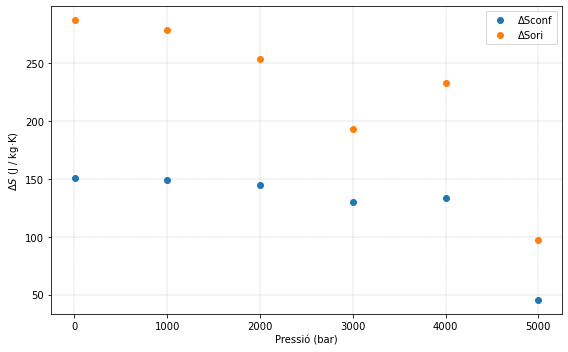

In [28]:
resultats = []

for  P in parelles:

    Sc = -entropy_conf(nou_abans(P)) + entropy_conf(nou_despres(P))
    Sc1 = entropy_conf(nou_abans(P))
    Sc2 = entropy_conf(nou_despres(P))
    So = -entropy_ori(nou_abans(P)) + entropy_ori(nou_despres(P))
    So1 = entropy_ori(nou_abans(P))
    So2 = entropy_ori(nou_despres(P))
    St = Sc + So

    resultats.append((P, T_a, T_b, Sc, So, St))
    print(f"P={P:5d} bar  {T_a}→{T_b} K Sc1={Sc1} Sc2={Sc2} Sc={Sc} So1={So1} So2={So2} So={So}  St={St}  J/(kg·K)")

# Plot
pressions = [r[0] for r in resultats]
Sc_list   = [r[3] for r in resultats]
So_list   = [r[4] for r in resultats]
St_list   = [r[5] for r in resultats]

plt.figure(figsize=(8,5))
plt.plot(pressions, Sc_list, 'o', label='ΔSconf')
plt.plot(pressions, So_list, 'o', label='ΔSori')
#plt.plot(pressions, St_list, 'o', label='ΔStotal')
plt.xlabel('Pressió (bar)')
plt.ylabel(r'$\Delta S$ (J / kg·K)')
plt.legend()
plt.grid(True, ls='--', lw=0.4)
plt.tight_layout()
plt.show()

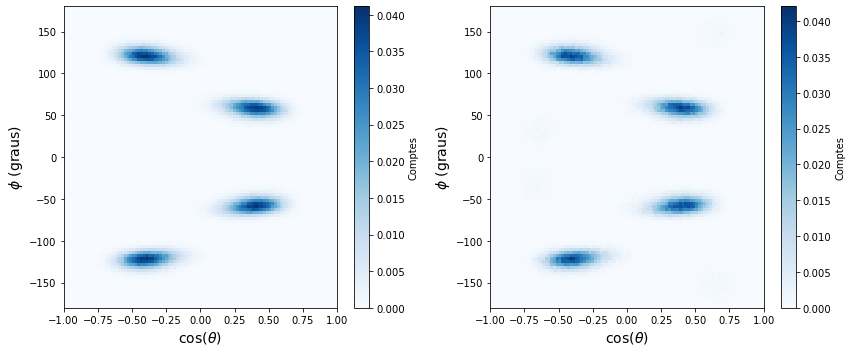

In [34]:
def read_theta_phior(filename):
    theta, phior = [], []
    with open(filename, "r") as f:
        lines = f.readlines()[4:-1]
    for line in lines:
        v = line.split()
        if len(v) >= 10:
            theta.append(float(v[8]))
            phior.append(float(v[9]))
    return np.array(theta), np.array(phior)

def compare_files_2d(file_list,
                     bins=100,
                     theta_range=(-1, 1),
                     phior_range=(-180, 180)):
    #labels = ['216', '512']
    cmaps  = ['Blues', 'Blues']

    fig, axes = plt.subplots(1, len(file_list), figsize=(6 * len(file_list), 5))
    if len(file_list) == 1:
        axes = [axes]

    for i, filename in enumerate(file_list):
        theta, phior = read_theta_phior(filename)

        hist, xedges, yedges = np.histogram2d(theta, phior, bins=bins,
                                               range=[theta_range, phior_range],density=True)
        mesh = axes[i].pcolormesh(xedges, yedges, hist.T,
                                   cmap=cmaps[i % len(cmaps)])
        #axes[i].set_title(labels[i], fontsize=14)
        axes[i].set_xlabel(r'$\cos(\theta)$', fontsize=14)
        axes[i].set_ylabel(r'$\phi$ (graus)', fontsize=14)
        fig.colorbar(mesh, ax=axes[i], label='Comptes')

    plt.tight_layout()
    #plt.savefig(f"{BASE}/figures/comparativa_2d.png", dpi=150)
    plt.show()


compare_files_2d([nou_abans(1),
antic_abans(1)
])

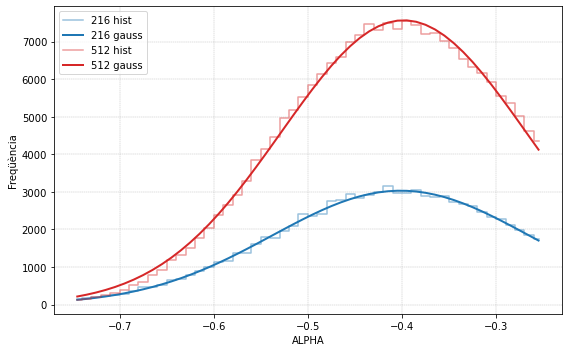

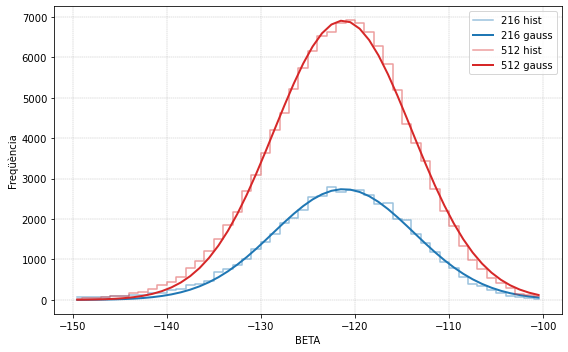

In [37]:
def gaussian(x, a, x0, sigma):
    return a * np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))

def read_theta_phior(filename):
    theta, phior = [], []
    with open(filename, "r") as f:
        lines = f.readlines()[4:-1]
    for line in lines:
        v = line.split()
        if len(v) >= 10:
            theta.append(float(v[8]))
            phior.append(float(v[9]))
    return np.array(theta), np.array(phior)

def fit_gaussian(data, bins=50, data_range=None):
    hist, edges = np.histogram(data, bins=bins, range=data_range,density=False)
    x = (edges[:-1] + edges[1:]) / 2
    p0 = [hist.max(), x[np.argmax(hist)], max(np.std(data), 1e-4)]
    try:
        popt, _ = curve_fit(gaussian, x, hist, p0=p0, maxfev=10000)
    except Exception:
        popt = p0
    return x, hist, popt

def compare_files(file_list,
                  theta_bins=50, theta_range=(-0.75,-0.25),
                  phior_bins=50, phior_range=(-150,-100)):
    colors = ["tab:blue", "tab:red", "tab:green", "tab:orange", "tab:purple"]
    labels = ['216','512']
    
    # Theta overlay
    plt.figure(figsize=(8,5))
    for i, filename in enumerate(file_list):
        theta, phior = read_theta_phior(filename)
        x_t, h_t, p_t = fit_gaussian(theta, bins=theta_bins, data_range=theta_range)
        plt.plot(x_t, h_t, drawstyle="steps-mid", color=colors[i%len(colors)], alpha=0.45, label=f"{labels[i]} hist")
        plt.plot(x_t, gaussian(x_t, *p_t), '-', color=colors[i%len(colors)], linewidth=2, label=f"{labels[i]} gauss")
    plt.xlabel("ALPHA")
    plt.ylabel("Freqüència")
    #plt.title("Comparativa Theta + Ajust Gaussià")
    plt.legend()
    plt.grid(True, ls="--", lw=0.4)
    plt.tight_layout()
    plt.savefig("/Users/aressanuylatorre/Desktop/doc/NPG/figures/comparativa_ori_des_2_a_nodens.png", dpi=150)
    plt.show()
    
    # Phior overlay
    plt.figure(figsize=(8,5))
    for i, filename in enumerate(file_list):
        theta, phior = read_theta_phior(filename)
        x_p, h_p, p_p = fit_gaussian(phior, bins=phior_bins, data_range=phior_range)
        plt.plot(x_p, h_p, drawstyle="steps-mid", color=colors[i%len(colors)], alpha=0.45, label=f"{labels[i]} hist")
        plt.plot(x_p, gaussian(x_p, *p_p), '-', color=colors[i%len(colors)], linewidth=2, label=f"{labels[i]} gauss")
    plt.xlabel("BETA")
    plt.ylabel("Freqüència")
    #plt.title("Comparativa Phior + Ajust Gaussià")
    plt.legend()
    plt.grid(True, ls="--", lw=0.4)
    plt.tight_layout()
    #plt.savefig("/Users/aressanuylatorre/Desktop/doc/NPG/figures/comparativa_ori_des_2_b_nodens.png", dpi=150)
    plt.show()

compare_files([
    antic_abans(1),
    nou_abans(1)
])


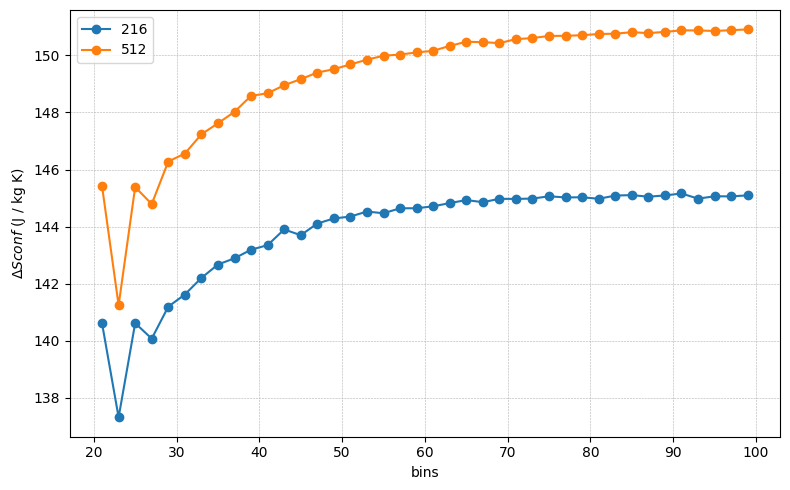

In [65]:

def compare_entropy_by_bins(bins_list,
                            file_216_a,
                            file_216_b,
                            file_512_a,
                            file_512_b):
    Sc216 = []
    Sc512 = []
    for b in bins_list:
        S216_a = entropy_conf(file_216_a, bins=b)
        S216_b = entropy_conf(file_216_b, bins=b)
        Sc216.append(S216_a - S216_b)

        S512_a = entropy_conf(file_512_a, bins=b)
        S512_b = entropy_conf(file_512_b, bins=b)
        Sc512.append(S512_a - S512_b)

    return np.array(Sc216), np.array(Sc512)

bins_list = np.arange(21, 101, 2)

file_216_a = antic_abans(305, 1)
file_216_b = antic_abans(300, 1)
file_512_a = nou_abans(305, 1)
file_512_b = nou_abans(300, 1)



Sc216, Sc512 = compare_entropy_by_bins(bins_list,
                                       file_216_a,
                                       file_216_b,
                                       file_512_a,
                                       file_512_b)




plt.figure(figsize=(8, 5))
plt.plot(bins_list, Sc216, '-o', label='216')
plt.plot(bins_list, Sc512, '-o', label='512')
plt.xlabel('bins')
plt.ylabel(r'$\Delta Sconf$ (J / kg K)')
plt.legend()
plt.grid(True, ls='--', lw=0.4)
plt.tight_layout()
plt.show()

bins= 20  So216=-2.351126e+02  So512=2.598644e+02  Snou=-2.833001e+02
bins= 40  So216=-2.643438e+02  So512=2.938781e+02  Snou=-3.248295e+02
bins= 60  So216=-2.554678e+02  So512=2.810974e+02  Snou=-3.266003e+02
bins= 80  So216=-2.325726e+02  So512=2.513740e+02  Snou=-3.109750e+02
bins=100  So216=-2.060006e+02  So512=2.190001e+02  Snou=-2.868860e+02
bins=120  So216=-1.798946e+02  So512=1.888029e+02  Snou=-2.603218e+02
bins=140  So216=-1.559252e+02  So512=1.621485e+02  Snou=-2.345615e+02


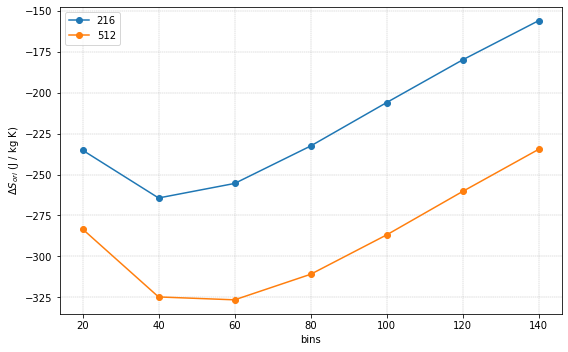

In [41]:
def compare_entropy_ori_by_bins(bins_list,
                                file_216_a, file_216_b,
                                file_512_a, file_512_b,
                                file_nou_a, file_nou_b):
    So216 = []
    So512 = []
    Snou  = []
    for b in bins_list:
        S216_a = entropy_ori(file_216_a, bins=b)
        S216_b = entropy_ori(file_216_b, bins=b)
        So216.append(S216_a - S216_b)

        S512_a = entropy_ori(file_512_a, bins=b)
        S512_b = entropy_ori(file_512_b, bins=b)
        So512.append(S512_a - S512_b)

        Snou_a = entropy_ori(file_nou_a, bins=b)
        Snou_b = entropy_ori(file_nou_b, bins=b)
        Snou.append(Snou_a - Snou_b)

    return np.array(So216), np.array(So512), np.array(Snou)

bins_list = np.arange(20, 151, 20)

file_216_a = antic_abans(1)
file_216_b = antic_despres(1)
file_512_a = "/Users/aressanuylatorre/Desktop/doc/NPG/antfiles/ang_ori_0_305.dat"
file_512_b = "/Users/aressanuylatorre/Desktop/doc/NPG/antfiles/ang_ori_0_300.dat"
file_nou_a = nou_abans(1)
file_nou_b = nou_despres(1)

So216, So512, Snou = compare_entropy_ori_by_bins(
    bins_list,
    file_216_a, file_216_b,
    file_512_a, file_512_b,
    file_nou_a, file_nou_b
)

for b, s216, s512, snou in zip(bins_list, So216, So512, Snou):
    print(f"bins={b:3d}  So216={s216:.6e}  So512={s512:.6e}  Snou={snou:.6e}")

plt.figure(figsize=(8, 5))
plt.plot(bins_list, So216, '-o', label='216')
#plt.plot(bins_list, So512, '-o', label='216 (nou)')
plt.plot(bins_list, Snou,  '-o', label='512')
plt.xlabel('bins')
plt.ylabel(r'$\Delta S_{ori}$ (J / kg K)')
plt.legend()
plt.grid(True, ls='--', lw=0.4)
plt.tight_layout()
plt.show()

bins= 20  So216=2.7422e+02 ± 2.8657e-01  So512=3.3043e+02 ± 1.5620e-01
bins= 40  So216=2.8520e+02 ± 2.9018e-01  So512=3.5046e+02 ± 1.6156e-01
bins= 60  So216=2.6868e+02 ± 2.7487e-01  So512=3.4349e+02 ± 1.5948e-01
bins= 80  So216=2.4152e+02 ± 2.5452e-01  So512=3.2293e+02 ± 1.5245e-01
bins=100  So216=2.1231e+02 ± 2.3468e-01  So512=2.9567e+02 ± 1.4422e-01
bins=120  So216=1.8447e+02 ± 2.1609e-01  So512=2.6694e+02 ± 1.3664e-01
bins=140  So216=1.5931e+02 ± 1.9981e-01  So512=2.3966e+02 ± 1.2977e-01
bins=160  So216=1.3733e+02 ± 1.8479e-01  So512=2.1445e+02 ± 1.2360e-01
bins=180  So216=1.1823e+02 ± 1.7102e-01  So512=1.9186e+02 ± 1.1797e-01
bins=200  So216=1.0167e+02 ± 1.5900e-01  So512=1.7155e+02 ± 1.1254e-01
bins=220  So216=8.7644e+01 ± 1.4753e-01  So512=1.5336e+02 ± 1.0738e-01
bins=240  So216=7.5479e+01 ± 1.3728e-01  So512=1.3728e+02 ± 1.0261e-01
bins=260  So216=6.5141e+01 ± 1.2789e-01  So512=1.2277e+02 ± 9.7989e-02
bins=280  So216=5.6189e+01 ± 1.1938e-01  So512=1.0991e+02 ± 9.3524e-02
bins=3

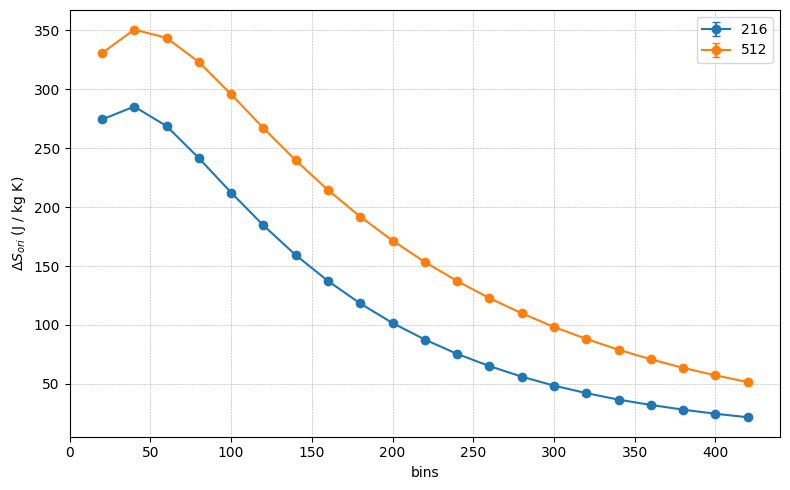

In [ ]:
def entropy_ori_with_error(fname, bins=70):
    """Entropia orientacional + error estadístic."""
    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(4):
            f.readline()
        for line in f:
            cols = line.split()
            try:
                th.append(float(cols[8]))
                phi.append(float(cols[9]))
                psi.append(float(cols[10]))
            except (IndexError, ValueError):
                continue

    intervals = [
        np.linspace(-1,   1,   bins),
        np.linspace(-180, 180, bins),
        np.linspace(-180, 180, bins),
    ]

    # Usem density=False per tenir counts bruts → necessari per l'error
    counts, _ = np.histogramdd((th, phi, psi), bins=intervals, density=False)
    N = counts.sum()

    Ath = 2 / bins
    A   = Ath * (360 / bins) * (360 / bins)
    p   = counts / N  # probabilitat per bin (sense density)

    mask = p > 0

    # Entropia (equivalent a l'original)
    S = -k * np.sum(p[mask] * np.log(p[mask] / A))  # corregim pel volum del bin

    # Error estadístic de Shannon
    log_p = np.log(p[mask] / A)
    E1 = np.sum(p[mask] * log_p**2)
    E2 = (np.sum(p[mask] * log_p))**2
    sigma_S = k * np.sqrt((E1 - E2) / N)

    S_scaled   = S / massa * nmol
    err_scaled = sigma_S / massa * nmol

    return S_scaled, err_scaledimport numpy as np

def entropy_conf(fname, bins):
    psi, phi = [], []
    with open(fname) as f:
        for _ in range(3):
            f.readline()
        for line in f:
            if not line.strip() or line.startswith('*'):
                continue
            cols = line.split()
            try:
                psi.append(float(cols[6]))
                phi.append(float(cols[7]))
            except (IndexError, ValueError):
                continue

    edges = np.linspace(-180, 180, bins + 1)
    hist, _, _ = np.histogram2d(psi, phi, bins=[edges, edges], density=True)
    Ap = 360.0 / bins
    p = hist * Ap * Ap
    S = -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(Ap * Ap)
    return S / massa * nmol



def compare_entropy_ori_by_bins(bins_list,
                                file_216_a, file_216_b,
                                file_512_a, file_512_b):
    So216, So512 = [], []
    Err216, Err512 = [], []

    for b in bins_list:
        S216_a, e216_a = entropy_ori_with_error(file_216_a, bins=b)
        S216_b, e216_b = entropy_ori_with_error(file_216_b, bins=b)
        So216.append(S216_a - S216_b)
        Err216.append(np.sqrt(e216_a**2 + e216_b**2))

        S512_a, e512_a = entropy_ori_with_error(file_512_a, bins=b)
        S512_b, e512_b = entropy_ori_with_error(file_512_b, bins=b)
        So512.append(S512_a - S512_b)
        Err512.append(np.sqrt(e512_a**2 + e512_b**2))

    return (np.array(So216), np.array(Err216),
            np.array(So512), np.array(Err512))


# ── execució ──────────────────────────────────────────────────────────────────
bins_list = np.arange(20, 421, 20)
file_216_a = antic_abans(305, 1)
file_216_b = antic_abans(300, 1)
file_512_a = nou_abans(305, 1)
file_512_b = nou_abans(300, 1)

So216, Err216, So512, Err512 = compare_entropy_ori_by_bins(
    bins_list,
    file_216_a, file_216_b,
    file_512_a, file_512_b
)

for b, s216, e216, s512, e512 in zip(bins_list, So216, Err216, So512, Err512):
    print(f"bins={b:3d}  So216={s216:.4e} ± {e216:.4e}  So512={s512:.4e} ± {e512:.4e}")

# ── plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.errorbar(bins_list, So216, yerr=Err216, fmt='-o', label='216', capsize=3)
plt.errorbar(bins_list, So512, yerr=Err512, fmt='-o', label='512', capsize=3)
plt.xlabel('bins')
plt.ylabel(r'$\Delta S_{ori}$ (J / kg K)')
plt.legend()
plt.grid(True, ls='--', lw=0.4)
plt.tight_layout()
def entropy_ori(fname, bins=70):
    """Entropia orientacional via histograma 3D (theta, phi, psi)."""
    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(4):
            f.readline()
        for line in f:
            cols = line.split()
            try:
                th.append(float(cols[8]))
                phi.append(float(cols[9]))
                psi.append(float(cols[10]))
            except (IndexError, ValueError):
                continue

    intervals = [
        np.linspace(-1,   1,   bins),
        np.linspace(-180, 180, bins),
        np.linspace(-180, 180, bins),
    ]
    hist, _ = np.histogramdd((th, phi, psi), bins=intervals, density=True)
    Ath = 2 / bins
    A   = Ath * (360 / bins) * (360 / bins)
    p   = hist * A
    S   = -k * np.sum(p[p > 0] * np.log(p[p > 0]))
    return S / massa * nmolplt.show()

bins= 20  So216=1.342561e+02  So512=1.458194e+02
bins= 40  So216=1.534713e+02  So512=1.663780e+02
bins= 60  So216=1.585280e+02  So512=1.719710e+02
bins= 80  So216=1.605613e+02  So512=1.744003e+02
bins=100  So216=1.616093e+02  So512=1.756690e+02


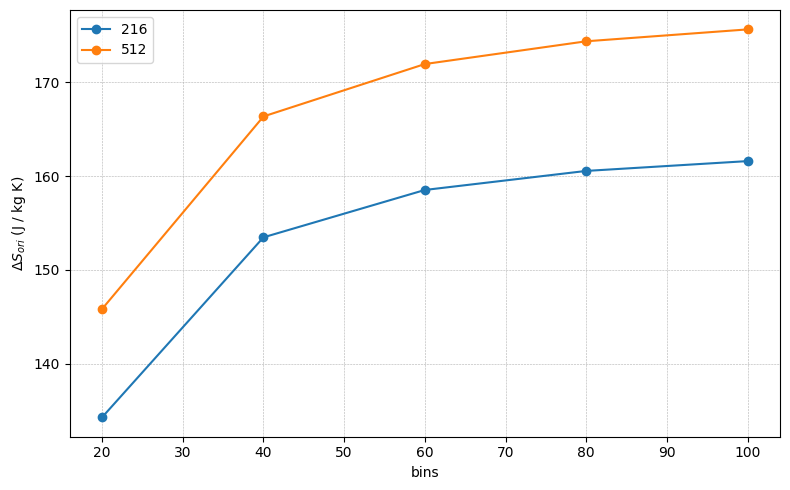

In [55]:
def entropy_ori2(fname, bins=70):
    """Entropia orientacional via histograma 3D (theta, phi, psi)."""
    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(4):
            f.readline()
        for line in f:
            cols = line.split()
            try:
                th.append(float(cols[8]))
                psi.append(float(cols[9]))
            except (IndexError, ValueError):
                continue

    intervals = [
        np.linspace(-1,   1,   bins),
        np.linspace(-180, 180, bins),
    ]
    hist, _ = np.histogramdd((th, psi), bins=intervals, density=True)
    Ath = 2 / bins
    A   = Ath * (360 / bins)
    p   = hist * A
    S   = -k * np.sum(p[p > 0] * np.log(p[p > 0]))
    return S / massa



def compare_entropy_ori_by_bins(bins_list,
                                file_216_a,
                                file_216_b,
                                file_512_a,
                                file_512_b):
    So216 = []
    So512 = []
    for b in bins_list:
        S216_a = entropy_ori2(file_216_a, bins=b)
        S216_b = entropy_ori2(file_216_b, bins=b)
        So216.append(S216_a - S216_b)

        S512_a = entropy_ori2(file_512_a, bins=b)
        S512_b = entropy_ori2(file_512_b, bins=b)
        So512.append(S512_a - S512_b)

    return np.array(So216), np.array(So512)

bins_list = np.arange(20, 101, 20)

file_216_a = antic_abans(305, 1)
file_216_b = antic_abans(300, 1)
file_512_a = nou_abans(305, 1)
file_512_b = nou_abans(300, 1)


So216, So512 = compare_entropy_ori_by_bins(
    bins_list,
    file_216_a, file_216_b,
    file_512_a, file_512_b
)

for b, s216, s512 in zip(bins_list, So216, So512):
    print(f"bins={b:3d}  So216={s216:.6e}  So512={s512:.6e}")

plt.figure(figsize=(8,5))
plt.plot(bins_list, So216, '-o', label='216')
plt.plot(bins_list, So512, '-o', label='512')
plt.xlabel('bins')
plt.ylabel(r'$\Delta S_{ori}$ (J / kg K)')
plt.legend()
plt.grid(True, ls='--', lw=0.4)
plt.tight_layout()
plt.show()

bins= 20  S216_a=5.767383e+02  S216_b=3.416257e+02  S512_a=6.052526e+02  S512_b=3.219526e+02  ΔS216=2.351126e+02  ΔS512=2.833001e+02
bins= 30  S216_a=6.877176e+02  S216_b=4.295647e+02  S512_a=7.223430e+02  S512_b=4.094884e+02  ΔS216=2.581529e+02  ΔS512=3.128546e+02
bins= 40  S216_a=7.610103e+02  S216_b=4.966665e+02  S512_a=8.016241e+02  S512_b=4.767946e+02  ΔS216=2.643438e+02  ΔS512=3.248295e+02
bins= 50  S216_a=8.126549e+02  S216_b=5.502155e+02  S512_a=8.591777e+02  S512_b=5.307206e+02  ΔS216=2.624394e+02  ΔS512=3.284571e+02
bins= 60  S216_a=8.496940e+02  S216_b=5.942262e+02  S512_a=9.018543e+02  S512_b=5.752540e+02  ΔS216=2.554678e+02  ΔS512=3.266003e+02
bins= 70  S216_a=8.765409e+02  S216_b=6.313454e+02  S512_a=9.333577e+02  S512_b=6.130923e+02  ΔS216=2.451956e+02  ΔS512=3.202654e+02
bins= 80  S216_a=8.957586e+02  S216_b=6.631860e+02  S512_a=9.568268e+02  S512_b=6.458518e+02  ΔS216=2.325726e+02  ΔS512=3.109750e+02
bins= 90  S216_a=9.104601e+02  S216_b=6.909900e+02  S512_a=9.741992e+

/tmp/ipykernel_1474934/1217028144.py:57: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(bins_list, So216, '-o', label='216 ΔS', linestyle='--')
/tmp/ipykernel_1474934/1217028144.py:58: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(bins_list, So512, '-o', label='512 ΔS', linestyle='--')


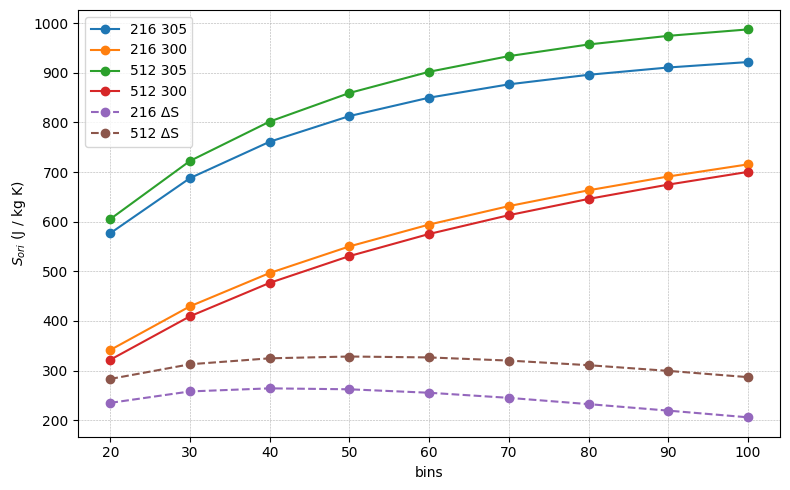

In [59]:
def compare_entropy_ori_by_bins(bins_list,
                                file_216_a,
                                file_216_b,
                                file_512_a,
                                file_512_b):
    S216_a_list = []
    S216_b_list = []
    S512_a_list = []
    S512_b_list = []
    So216 = []
    So512 = []

    for b in bins_list:
        S216_a = entropy_ori(file_216_a, bins=b)
        S216_b = entropy_ori(file_216_b, bins=b)
        S512_a = entropy_ori(file_512_a, bins=b)
        S512_b = entropy_ori(file_512_b, bins=b)

        S216_a_list.append(S216_a)
        S216_b_list.append(S216_b)
        S512_a_list.append(S512_a)
        S512_b_list.append(S512_b)

        So216.append(S216_a - S216_b)
        So512.append(S512_a - S512_b)

    return (np.array(S216_a_list), np.array(S216_b_list),
            np.array(S512_a_list), np.array(S512_b_list),
            np.array(So216), np.array(So512))


bins_list = np.arange(20, 101, 10)

file_216_a = antic_abans(305, 1)
file_216_b = antic_abans(300, 1)
file_512_a = nou_abans(305, 1)
file_512_b = nou_abans(300, 1)

S216_a, S216_b, S512_a, S512_b, So216, So512 = compare_entropy_ori_by_bins(
    bins_list,
    file_216_a, file_216_b,
    file_512_a, file_512_b
)

for b, s216a, s216b, s512a, s512b, s216, s512 in zip(
        bins_list, S216_a, S216_b, S512_a, S512_b, So216, So512):
    print(f"bins={b:3d}  S216_a={s216a:.6e}  S216_b={s216b:.6e}  "
          f"S512_a={s512a:.6e}  S512_b={s512b:.6e}  "
          f"ΔS216={s216:.6e}  ΔS512={s512:.6e}")

plt.figure(figsize=(8, 5))
#ori=65 / 
plt.plot(bins_list, S216_a, '-o', label='216 305')
plt.plot(bins_list, S216_b, '-o', label='216 300')
plt.plot(bins_list, S512_a, '-o', label='512 305')
plt.plot(bins_list, S512_b, '-o', label='512 300')
plt.plot(bins_list, So216, '-o', label='216 ΔS', linestyle='--')
plt.plot(bins_list, So512, '-o', label='512 ΔS', linestyle='--')
plt.xlabel('bins')
plt.ylabel(r'$S_{ori}$ (J / kg K)')
plt.legend()
plt.grid(True, ls='--', lw=0.4)
plt.tight_layout()
plt.show()